# Security Harmonization in Hybrid Post-Quantum KEM + Symmetric Encryption Architectures Under Quantum Adversary Models

# Table of Contents

1. [Abstract](#1.-Abstract)
2. [Threat Model](#2.-Threat-Model)
3. [Shor’s Algorithm and Its Impact on RSA](#3.-Shor’s-Algorithm-and-Its-Impact-on-RSA)
4. [Grover’s Algorithm and Its Impact on AES](#4.-Grover’s-Algorithm-and-Its-Impact-on-AES)
5. [CRYSTALS-Kyber Overview](#5.-CRYSTALS-Kyber-Overview)
6. [Hybrid Architecture Design](#6.-Hybrid-Architecture-Design)
7. [Implementation](#7.-Implementation)
8. [Performance Benchmark](#8.-Performance-Benchmark)
9. [Discussion](#9.-Discussion)
10. [Conclusion](#10.-Conclusion)
11. [References](#References)

## 1. Abstract
<p id=1 align="justify">
The imminent development of large-scale quantum computers introduces asymmetric impacts on modern cryptographic systems. Public-key schemes such as RSA and ECC are theoretically vulnerable to Shor’s algorithm [1], while symmetric primitives like AES are affected more moderately through Grover’s quadratic speedup [2]. As a result, designing quantum-resilient systems requires holistic analysis across both asymmetric and symmetric layers.
</p>
<p align="justify">
In this notebook, we investigate the security parameter alignment between lattice-based Key Encapsulation Mechanisms (KEMs), specifically CRYSTALS-Kyber as standardized by NIST, and symmetric encryption mechanisms such as AES-GCM within a hybrid post-quantum architecture.
</p>
<p align="justify">
We formalize a composite security model in which the overall system security is bounded by the minimum effective security of its components under a realistic quantum adversary model. We provide:


* A complexity analysis of Shor’s algorithm against RSA
* A quantum cost model for Grover’s search applied to AES key spaces
* A parameter harmonization study between Kyber security levels and AES key sizes 
* A hybrid KEM design combining classical and post-quantum primitives  
* Empirical simulations and visualizations of effective security degradation  


Our results demonstrate that post-quantum migration is not solely an asymmetric cryptography problem. Instead, security harmonization between KEM parameters and symmetric key sizes is essential to avoid hidden bottlenecks in future quantum threat environments.
</p>

## 2. Threat Model

<p style="text-align: justify;">
    
A rigorous security evaluation requires explicit adversarial assumptions. In this study, we distinguish between two adversary models: a classical computational adversary and a quantum-capable adversary. The objective is to evaluate how hybrid cryptographic architectures behave under both threat models and to identify security bottlenecks that emerge in the presence of quantum acceleration.

</p>

### 2.1. Classical Adversary

<p style="text-align: justify;">

The classical adversary is assumed to operate under probabilistic polynomial-time (PPT) constraints. 
This adversary has no access to quantum computational capabilities and is limited to classical algorithms for integer factorization, discrete logarithm computation, and brute-force key search.

Under this model:

• RSA security relies on the computational hardness of integer factorization.  
• ECC security relies on the hardness of the elliptic curve discrete logarithm problem (ECDLP).  
• AES security relies on exhaustive key search complexity O(2^n).

Security levels are therefore determined directly by classical computational cost.

</p>


### 2.2. Quantum Adversary

<p style="text-align: justify;">

The quantum adversary is assumed to possess access to a fault-tolerant, large-scale quantum computer capable of executing polynomial-time quantum algorithms.

Under this model:

• Public-key schemes based on integer factorization and discrete logarithms become polynomial-time solvable via Shor’s algorithm [3].  
• Symmetric algorithms such as AES are affected by Grover’s algorithm [4], which reduces brute-force search complexity from $O(2^n)$ to $O(2^{n/2})$.  

Importantly, Grover’s algorithm <b>does not render symmetric encryption insecure</b>, but effectively halves the security exponent. Consequently, AES-128 provides approximately 64 bits of post-quantum security, while AES-256 retains approximately 128 bits of effective quantum resistance.

In this work, we assume an adversary capable of implementing idealized versions of these quantum algorithms and evaluate system security under this upper-bound threat model.

</p>

## 3. Shor’s Algorithm and Its Impact on RSA

### 3.1. Integer Factorization and RSA Security

RSA security relies on the computational hardness of the integer factorization problem.

Given:

$$
N = p \cdot q
$$

where $p$ and $q$ are large primes, recovering $p$ and $q$ from $N$ is assumed to be computationally infeasible for classical adversaries.

Classically, the best known factoring algorithms (e.g., General Number Field Sieve) run in sub-exponential time:

$$
L_N[1/3] = \exp\left((\frac{64}{9})^{1/3} (\log N)^{1/3} (\log \log N)^{2/3}\right)
$$

which is super-polynomial and computationally prohibitive for sufficiently large key sizes (e.g., RSA-2048).


### 3.2. Quantum Reduction via Shor’s Algorithm

Shor’s algorithm [5] reduces integer factorization to a period-finding problem that can be solved efficiently using quantum Fourier transform.

The time complexity becomes:

$$
O((\log N)^3)
$$

which is polynomial in the size of the input.

This represents an exponential speedup compared to the best known classical factoring algorithms.


### 3.3. Security Implications

Under a sufficiently large fault-tolerant quantum computer, RSA security collapses from sub-exponential hardness to polynomial-time solvability. 

Consequently, <b>RSA key size increases do not provide meaningful post-quantum protection</b>, as polynomial-time quantum algorithms scale efficiently even for large moduli.

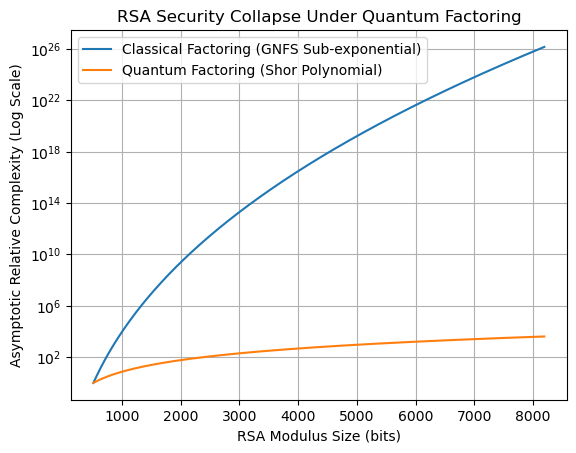

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# RSA key size in bits
n = np.linspace(512, 8192, 300)

# GNFS complexity approximation in terms of bit-length n
classical = np.exp(
    (n**(1/3)) * (np.log(n)**(2/3))
)

# Shor polynomial complexity
quantum = n**3

# Normalize for visual comparison
classical = classical / classical[0]
quantum = quantum / quantum[0]

plt.figure()

plt.plot(n, classical, label="Classical Factoring (GNFS Sub-exponential)")
plt.plot(n, quantum, label="Quantum Factoring (Shor Polynomial)")

plt.xlabel("RSA Modulus Size (bits)")
plt.ylabel("Asymptotic Relative Complexity (Log Scale)")
plt.title("RSA Security Collapse Under Quantum Factoring")

plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

## 4. Grover’s Algorithm and Its Impact on AES

### 4.1. Classical Brute-Force Complexity

For an n-bit symmetric key, classical exhaustive key search requires:

$$
O(2^n)
$$

operations.

This exponential growth in key size defines the effective security level of symmetric encryption schemes such as AES.


### 4.2. Quantum Reduction via Grover’s Algorithm

Grover’s algorithm [6] reduces unstructured search complexity from:

$$
O(2^n)
$$

to:

$$
O(2^{n/2})
$$

This represents a quadratic speedup, not an exponential collapse.

Consequently:

- AES-128 → effective quantum security ≈ 64 bits  
- AES-256 → effective quantum security ≈ 128 bits

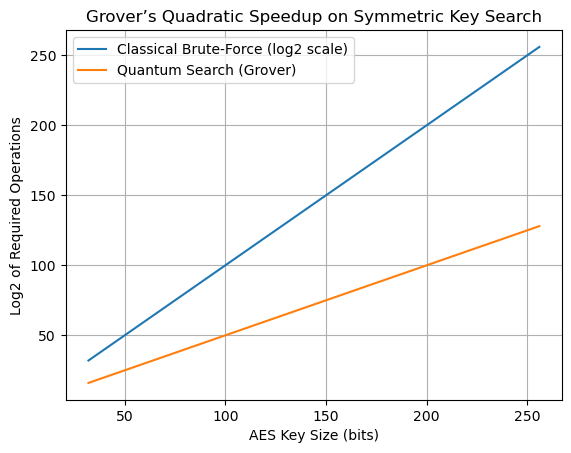

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Key sizes
n = np.linspace(32, 256, 200)

# Classical brute-force complexity (log2 scale)
classical = n

# Grover complexity (log2 scale)
quantum = n / 2

plt.figure()

plt.plot(n, classical, label="Classical Brute-Force (log2 scale)")
plt.plot(n, quantum, label="Quantum Search (Grover)")

plt.xlabel("AES Key Size (bits)")
plt.ylabel("Log2 of Required Operations")
plt.title("Grover’s Quadratic Speedup on Symmetric Key Search")

plt.legend()
plt.grid(True)

plt.show()

Unlike Shor’s algorithm, Grover’s algorithm does not render symmetric encryption polynomial-time solvable. Instead, it effectively halves the security exponent, allowing security restoration through increased key length.

## 5. CRYSTALS-Kyber Overview
### 5.1. NIST Post-Quantum Standardization

<p style="text-align: justify;">
CRYSTALS-Kyber was selected by the National Institute of Standards and Technology (NIST) in 2022 for standardization as a post-quantum key encapsulation mechanism (KEM) [7].

Kyber is standardized in:

NIST FIPS 203 — Module-Lattice-Based Key-Encapsulation Mechanism Standard (ML-KEM).

Unlike RSA, whose security is based on integer factorization, Kyber relies on the hardness of structured lattice problems believed to be resistant to both classical and quantum attacks.
</p>


### 5.2. Learning With Errors (LWE) Assumption

Kyber’s security is based on the hardness of the Module Learning With Errors (Module-LWE) problem.

Informally, the LWE problem can be stated as:

Given:

$$
\mathbf{A} \in \mathbb{Z}_q^{m \times n}, \quad 
\mathbf{s} \in \mathbb{Z}_q^n
$$

and noisy samples:

$$
\mathbf{b} = \mathbf{A}\mathbf{s} + \mathbf{e} \mod q
$$

recovering the secret vector $\mathbf{s}$ is computationally infeasible.

The addition of noise $\mathbf{e}$ prevents efficient linear algebraic recovery.


### 5.3. Security Levels

Kyber defines multiple parameter sets:

• Kyber-512  
• Kyber-768  
• Kyber-1024  

These correspond approximately to classical security levels of:

• ~128 bits  
• ~192 bits  
• ~256 bits  

Importantly, these estimates already consider the best known classical and quantum lattice attacks.



### 5.4. Quantum Resistance Considerations
<p style="text-align: justify;">
Unlike RSA, lattice-based schemes such as Kyber do not rely on integer factorization or discrete logarithms.

Shor’s algorithm provides no known efficient reduction for solving lattice problems such as Module-LWE.

While quantum speedups exist for certain lattice reductions, no polynomial-time quantum algorithm comparable to Shor’s algorithm is known for LWE-type problems.
</p>


## 6. Hybrid Architecture Design

### 6.1. Design Rationale

A secure post-quantum communication architecture must address two distinct attack vectors:

1. Asymmetric cryptanalysis (Shor’s algorithm)
2. Symmetric brute-force acceleration (Grover’s algorithm)

Replacing RSA with a post-quantum KEM such as CRYSTALS-Kyber mitigates polynomial-time quantum factoring. However, symmetric encryption remains subject to quadratic quantum speedup.

Therefore, a hybrid architecture must ensure security alignment between:

- KEM security level
- Symmetric key length


### 6.2. System Components

The proposed hybrid architecture consists of a post-quantum key encapsulation mechanism (KEM), a NIST-compliant key derivation function (KDF) [8][9], and authenticated symmetric encryption using AES-GCM [10].

1. Post-Quantum Key Encapsulation (CRYSTALS-Kyber)
2. Classical symmetric encryption (AES-GCM)
3. Key derivation function (HKDF)

The KEM establishes a shared secret:

$$
K_{shared}
$$

which is expanded via HKDF to derive a session key:

$$
K_{AES}
$$

for authenticated encryption.


### 6.3. Composite Security Model

Let:

- $S_{KEM}$ = effective security level of the KEM (in bits)
- $S_{SYM}$ = effective symmetric security under quantum search

The overall system security is bounded by:

$$
S_{total} = \min(S_{KEM}, S_{SYM})
$$

This reflects the <b>standard weakest-link principle</b> in cryptographic composition.


### 6.4. Security Harmonization Requirement

Under a quantum adversary:

$$
S_{SYM} = \frac{n}{2}
$$

where $n$ is the AES key size.

Therefore, to match Kyber-512 (~128-bit security), the symmetric layer must satisfy:

$$
\frac{n}{2} \geq 128
$$

which implies:

$$
n \geq 256
$$

Thus, AES-256 is required to maintain security alignment with Kyber-512 under Grover’s model.

---

### 6.5. Security Level Harmonization

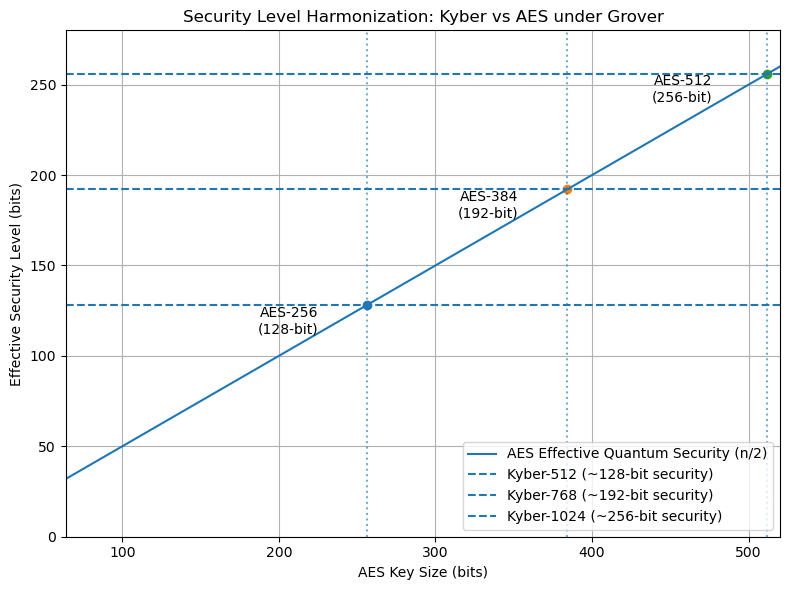

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# AES key sizes (bits)
aes_key_sizes = np.linspace(64, 520, 300)

# Effective quantum symmetric security under Grover
aes_quantum_security = aes_key_sizes / 2

# Kyber security levels
kyber_levels = {
    "Kyber-512 (~128-bit security)": 128,
    "Kyber-768 (~192-bit security)": 192,
    "Kyber-1024 (~256-bit security)": 256
}

plt.figure(figsize=(8,6))

# AES curve
plt.plot(aes_key_sizes, aes_quantum_security,
         label="AES Effective Quantum Security (n/2)")

for label, sec in kyber_levels.items():
    plt.axhline(sec, linestyle="--", label=label)

    aes_required = 2 * sec
    plt.scatter(aes_required, sec)

    plt.axvline(aes_required, linestyle=":", alpha=0.6)

    if sec == 256:
        offset = (-40, -20)  
    else:
        offset = (-35, -20)

    plt.annotate(f"AES-{aes_required}\n({sec}-bit)",
                 (aes_required, sec),
                 textcoords="offset points",
                 xytext=offset,
                 ha="right")

plt.xlabel("AES Key Size (bits)")
plt.ylabel("Effective Security Level (bits)")
plt.title("Security Level Harmonization: Kyber vs AES under Grover")

plt.xlim(64, 520)
plt.ylim(0, 280)

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="text-align: justify;">
The intersection points illustrate the minimum symmetric key size required to maintain security alignment with each Kyber parameter set under Grover’s quadratic speedup model. 

This demonstrates that post-quantum migration is not solely an asymmetric replacement problem, but a parameter harmonization problem across cryptographic layers.
</p>

---

### 6.6. Protocol Flow

The hybrid architecture separates quantum-resistant key establishment from classical symmetric encryption in a structured and secure workflow.

#### 6.6.1. Server Key Generation

The server generates an ML-KEM-512 key pair:

- `public_key`
- `private_key`

The private key remains securely stored on the server.

#### 6.6.2. Public Key Distribution

The server transmits the `public_key` to the client.


#### 6.6.3. Client Encapsulation

Using the received public key, the client performs encapsulation. This produces:

- a `ciphertext`
- a `shared secret`

Only the `ciphertext` is transmitted back to the server. The shared secret is **never** sent over the network.


#### 6.6.4. Server Decapsulation

The server uses its `private_key` together with the received `ciphertext` to recover the same shared secret.

At this point:

- Client and server independently hold an identical shared secret.
- No symmetric key has been transmitted.


#### 6.6.5. Session Key Derivation (HKDF)

Both parties derive the same 256-bit AES session key using HKDF:

<code>aes_key = HKDF(shared_secret)</code>

This produces a deterministic, length-constrained AES-256 key. The AES key is never transmitted.


#### 6.6.6. Authenticated Encryption (AES-256-GCM)

The client encrypts application data using:

- `aes_key`
- a unique `nonce`

The client sends:

- `nonce`
- `ciphertext`

The nonce is not secret but must be unique per encryption.

#### 6.6.7. Server Decryption

The server decrypts the ciphertext using the same derived `aes_key` and the transmitted `nonce`.


#### 6.6.8. Architectural Summary

- ML-KEM provides quantum-resistant key establishment.
- HKDF derives a symmetric session key from the shared secret.
- AES-256-GCM performs efficient authenticated bulk encryption.

**The post-quantum KEM ensures quantum-resistant key establishment, while AES-256-GCM provides efficient authenticated data encryption.**

## 7. Implementation

###  7.1. Library Installation

The implementation requires the following Python packages:

In [2]:
!pip install pqcrypto
!pip install cryptography

  Using cached pqcrypto-0.4.0-cp311-cp311-win_amd64.whl (5.4 MB)


<b>Windows Users (Important)</b>
<p style="text-align: justify;">
    On Windows systems, <code>pqcrypto</code> may require C build tools depending on the Python distribution and environment.
</p>
<p style="text-align: justify;">
If installation fails, ensure that the following components are installed via <b>Visual Studio Build Tools</b>:
 
* Desktop development with C++
* MSVC v143 toolset (or latest MSVC toolchain)
* Windows 10/11 SDK
* CMake tools for Windows

After installing these components, restart the terminal and reinstall <code>pqcrypto</code>.
</p>

---

### 7.2. Kyber Key Exchange

In [2]:
from secrets import compare_digest
from pqcrypto.kem.ml_kem_512 import generate_keypair, encrypt, decrypt

# Server generates (public, secret) key pair
public_key, secret_key = generate_keypair()

# Client encapsulates shared secret using server's public key
ciphertext, shared_secret_client = encrypt(public_key)

# Server decapsulates shared secret
shared_secret_server = decrypt(secret_key, ciphertext)

# Constant-time comparison: prevents timing side-channel leakage by comparing all bytes regardless of mismatch position
assert compare_digest(shared_secret_client, shared_secret_server)

print("Shared secret established successfully.")
print("Shared secret length (bytes):", len(shared_secret_client))

Shared secret established successfully.
Shared secret length (bytes): 32


**Timing side-channel leakage**
<p style="text-align: justify;">
In naive equality checks, comparison may stop at the first mismatching byte, causing the execution time to vary depending on how many initial bytes match. An attacker observing precise timing differences could potentially infer partial information about secret values.
</p>
<p style="text-align: justify;">
The <code>compare_digest</code> function avoids this by performing a constant-time comparison, evaluating all bytes regardless of mismatch position. This ensures that comparison time does not depend on the content of the shared secret.
</p>
<p style="text-align: justify;">
While not central to our hybrid PQC architecture, this reflects secure implementation best practices.
</p>

### 7.3. AES Key Derivation using HKDF

In [7]:
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.backends import default_backend
import os

# Derive AES-256 key
hkdf = HKDF(
    algorithm=hashes.SHA256(),
    length=32,  # 32 bytes = 256 bits
    salt=None,
    info=b'hybrid encryption',
    backend=default_backend()
)

aes_key = hkdf.derive(shared_secret_client)

print("AES-256 key derived.")
print("Key length:", len(aes_key))

AES-256 key derived.
Key length: 32


### 7.4. Encryption with AES-GCM

In [11]:
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

aesgcm = AESGCM(aes_key)

nonce = os.urandom(12)
plaintext = b"Post-Quantum Hybrid Encryption Demo"

ciphertext = aesgcm.encrypt(nonce, plaintext, None)

print("Ciphertext:", ciphertext)

Ciphertext: b'\xfd!\xb2\n\x18\\@\xec\xc9m\xa9Q,\xa7w\x881^\xb6\xe3T\x00>\x9ae#\x08.\x9f<L\xcd\xb5\xb6\x8a;Oj\x96b\xe8\x9d\x18+ +\xba\xa0-\xb2@'


### 7.5. Decryption

In [12]:
decrypted = aesgcm.decrypt(nonce, ciphertext, None)

print("Decrypted:", decrypted)

Decrypted: b'Post-Quantum Hybrid Encryption Demo'


# 8. Performance Benchmark

<p style="text-align: justify;">
This section evaluates the computational cost of classical and post-quantum key establishment mechanisms under two distinct scenarios:

1. Long-term key generation cost
2. Per-session key establishment cost (excluding key generation)

All measurements are averaged over multiple independent iterations to reduce timing noise.
</p>

## 8.1. Key Generation Benchmark

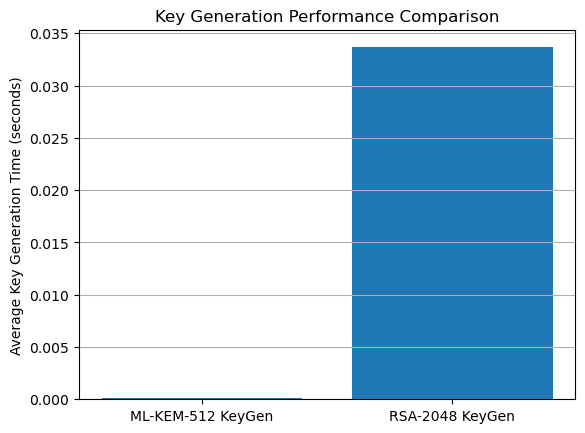

Average ML-KEM KeyGen time: 9.884198196232319e-05
Average RSA-2048 KeyGen time: 0.03366622200235724


In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# ML-KEM Key Generation Benchmark
# -----------------------------
from pqcrypto.kem.ml_kem_512 import generate_keypair

kem_iterations = 50
kem_keygen_times = []

for _ in range(kem_iterations):
    start = time.perf_counter()
    
    public_key, secret_key = generate_keypair()
    
    end = time.perf_counter()
    kem_keygen_times.append(end - start)

kem_keygen_avg = np.mean(kem_keygen_times)


# -----------------------------
# RSA Key Generation Benchmark
# -----------------------------
from cryptography.hazmat.primitives.asymmetric import rsa

rsa_iterations = 50
rsa_keygen_times = []

for _ in range(rsa_iterations):
    start = time.perf_counter()
    
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048,
    )
    
    end = time.perf_counter()
    rsa_keygen_times.append(end - start)

rsa_keygen_avg = np.mean(rsa_keygen_times)


# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.bar(
    ["ML-KEM-512 KeyGen", "RSA-2048 KeyGen"],
    [kem_keygen_avg, rsa_keygen_avg]
)

plt.ylabel("Average Key Generation Time (seconds)")
plt.title("Key Generation Performance Comparison")

plt.grid(True, axis='y')
plt.show()

print("Average ML-KEM KeyGen time:", kem_keygen_avg)
print("Average RSA-2048 KeyGen time:", rsa_keygen_avg)

<p style="text-align: justify;">
This benchmark measures long-term key generation cost.

RSA key generation involves probabilistic large prime generation,  while ML-KEM key generation relies on structured lattice operations.

The results illustrate the structural computational differences between  classical factorization-based and lattice-based cryptography.
</p>

---

## 8.2. Per-Session Key Establishment Benchmark

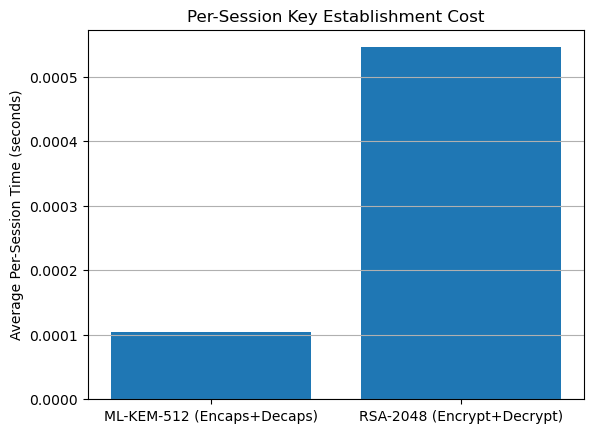

Average ML-KEM per-session time: 0.00010363898705691099
Average RSA per-session time: 0.000545532014220953


In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
from secrets import compare_digest

# -----------------------------
# ML-KEM Setup
# -----------------------------
from pqcrypto.kem.ml_kem_512 import generate_keypair, encrypt, decrypt

kem_public_key, kem_secret_key = generate_keypair()

kem_iterations = 100
kem_times = []

for _ in range(kem_iterations):
    start = time.perf_counter()
    
    ciphertext, ss_client = encrypt(kem_public_key)
    ss_server = decrypt(kem_secret_key, ciphertext)
    
    assert compare_digest(ss_client, ss_server)
    
    end = time.perf_counter()
    kem_times.append(end - start)

kem_avg = np.mean(kem_times)


# -----------------------------
# RSA Setup
# -----------------------------
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes

rsa_private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048,
)

rsa_public_key = rsa_private_key.public_key()

rsa_iterations = 100
rsa_times = []

for _ in range(rsa_iterations):
    start = time.perf_counter()
    
    message = b"benchmark"
    
    ciphertext = rsa_public_key.encrypt(
        message,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    
    decrypted = rsa_private_key.decrypt(
        ciphertext,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    
    end = time.perf_counter()
    rsa_times.append(end - start)

rsa_avg = np.mean(rsa_times)


# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.bar(
    ["ML-KEM-512 (Encaps+Decaps)", "RSA-2048 (Encrypt+Decrypt)"],
    [kem_avg, rsa_avg]
)

plt.ylabel("Average Per-Session Time (seconds)")
plt.title("Per-Session Key Establishment Cost")

plt.grid(True, axis='y')
plt.show()

print("Average ML-KEM per-session time:", kem_avg)
print("Average RSA per-session time:", rsa_avg)

<p style="text-align: justify;">
This benchmark measures per-session cryptographic cost, excluding key generation.

Results show that ML-KEM encapsulation/decapsulation is competitive with RSA encryption/decryption under realistic deployment assumptions where long-term keys are pre-generated.
</p>
<p style="text-align: justify;">
Post-quantum cryptography does not introduce prohibitive performance overhead at the session level.
</p>

<b>Note:</b> Absolute performance values depend on hardware and implementation details. 
The results illustrate relative structural differences rather than universal timing guarantees.

## 8.3. Benchmark Environment

* CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel
* RAM (GB): 15.85
* Operating System: Windows 11
* Python Version: 3.11.3 | packaged by Anaconda, Inc. | (main, Apr 19 2023, 23:46:34) [MSC v.1916 64 bit (AMD64)]

## 9. Discussion

This study examined the structural and performance implications of transitioning from classical public-key cryptography to post-quantum mechanisms within a hybrid architecture.

### 9.1 Structural Security Implications

Theoretical analysis confirms the asymmetric impact of quantum computing on modern cryptography:

- Public-key systems based on integer factorization and discrete logarithms become polynomial-time solvable under Shor’s algorithm.
- Symmetric cryptography is affected more moderately through Grover’s quadratic speedup.

This distinction implies that post-quantum migration is primarily an asymmetric replacement problem rather than a complete cryptographic redesign.

However, symmetric parameters must still be harmonized to maintain security alignment. The security harmonization analysis demonstrated that AES-256 is required to match the ~128-bit post-quantum security level provided by ML-KEM-512.


### 9.2 Performance Implications

Benchmark results reveal two key observations:

1. RSA key generation is significantly more computationally expensive than ML-KEM key generation.
2. At the per-session level, ML-KEM encapsulation/decapsulation is competitive with, and in this environment faster than, RSA encryption/decryption.

These findings challenge the common assumption that post-quantum cryptography necessarily introduces prohibitive performance overhead.

Importantly, performance results are implementation- and hardware-dependent; however, the structural computational differences between lattice-based and factorization-based systems are clearly observable.


### 9.3 Hybrid Architecture Justification

The hybrid model (ML-KEM + AES-256-GCM) provides:

- Quantum-resistant key establishment
- Efficient authenticated symmetric encryption
- Parameter alignment under Grover’s attack model
- Practical deployability with minimal architectural change

This architecture represents a realistic and incremental migration path rather than a disruptive redesign.


### 9.4 Limitations

This study does not evaluate:

- Side-channel resistance
- Constant-time implementation guarantees
- Fault-tolerant quantum resource requirements
- Network-layer overhead (e.g., key and ciphertext sizes)

Future work may incorporate bandwidth analysis, memory footprint comparison, and TLS-level integration benchmarks.

## 10. Conclusion

This study analyzed the theoretical and practical implications of post-quantum migration through a structured comparison of classical RSA-based key establishment and a hybrid ML-KEM + AES-256 architecture.

Theoretical analysis demonstrated that public-key systems based on integer factorization are fundamentally vulnerable under Shor’s algorithm, while symmetric cryptography is only quadratically affected under Grover’s model. This asymmetry establishes post-quantum transition as primarily an asymmetric cryptographic replacement problem, accompanied by necessary symmetric parameter harmonization.

Security alignment analysis showed that AES-256 is required to maintain balanced protection when paired with ML-KEM-512 under a quantum threat model.

Empirical benchmarks further indicate that:

- ML-KEM key generation is significantly more efficient than RSA key generation.
- Per-session ML-KEM encapsulation/decapsulation is computationally competitive with RSA encryption/decryption.
- Post-quantum cryptography does not inherently introduce prohibitive performance overhead.

These findings support the feasibility of hybrid post-quantum architectures in real-world deployments.

Ultimately, the results suggest that post-quantum migration is less a question of technical feasibility and more a question of ecosystem maturity, protocol integration, and standardization readiness.

## References

[1] *Report on Post-Quantum Cryptography*, National Institute of Standards and Technology (NIST) Technical Report IR 8105, April 2016. Available: https://nvlpubs.nist.gov/nistpubs/ir/2016/NIST.IR.8105.pdf

[2] Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. Proceedings of the 28th Annual ACM Symposium on Theory of Computing (STOC). https://doi.org/10.1145/237814.237866

[3] Shor, P. W. (1994). Algorithms for quantum computation: discrete logarithms and factoring. Proceedings 35th Annual Symposium on Foundations of Computer Science (FOCS 1994). 
https://doi.org/10.1109/SFCS.1994.365700

[4] Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. Proceedings of the 28th Annual ACM Symposium on Theory of Computing (STOC). https://doi.org/10.1145/237814.237866

[5] P. W. Shor, "Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer," SIAM Journal on Computing, vol. 26, no. 5, pp. 1484–1509, 1997. 
https://doi.org/10.1137/S0097539795293172

[6] L. K. Grover, "A Fast Quantum Mechanical Algorithm for Database Search," Proceedings of the 28th Annual ACM Symposium on Theory of Computing (STOC), 1996. 
https://doi.org/10.1145/237814.237866

[7] NIST FIPS 203, ML-KEM (2024)
https://csrc.nist.gov/pubs/fips/203/final

[8] NIST Special Publication 800-56C Rev.2, 
Recommendation for Key-Derivation Methods in Key-Establishment Schemes, 2020.  
https://doi.org/10.6028/NIST.SP.800-56Cr2

[9] Krawczyk, H., & Eronen, P. (2010). 
HMAC-based Extract-and-Expand Key Derivation Function (HKDF). 
RFC 5869.  
https://www.rfc-editor.org/rfc/rfc5869

[10] NIST FIPS 197, 
Advanced Encryption Standard (AES), 2001 (Updated 2023).  
https://csrc.nist.gov/pubs/fips/197/final


## Author

Koray Danışma  
Security Researcher | Offensive Security Engineer

- LinkedIn: [koray-danışma](https://tr.linkedin.com/in/koray-seyfullah-dan%C4%B1%C5%9Fma-a31660a4)  
- GitHub: [koraydns](https://github.com/koraydns)